In [1]:
!pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/flights.csv"
df = pd.read_csv(url)
df.head()


,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


In [3]:
df['Date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
df = df.rename(columns={'passengers': 'Sales'})
df = df.sort_values('Date')

df.isnull().sum()

df['Sales'] = df['Sales'].fillna(method='ffill')

/tmp/ipython-input-566697946.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Sales'] = df['Sales'].fillna(method='ffill')


In [4]:
df = df.set_index('Date')
daily_sales = df['Sales'].resample('D').sum().reset_index()


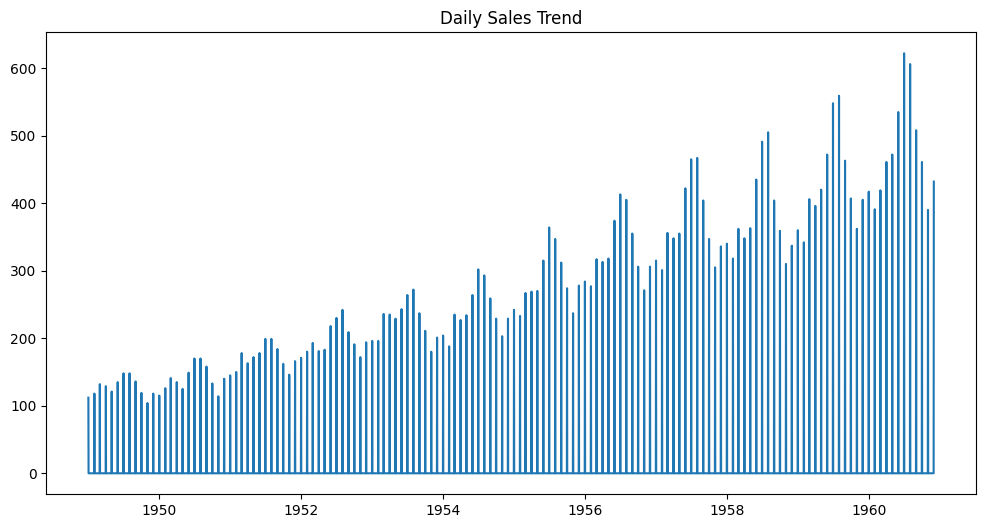

In [5]:
plt.figure(figsize=(12,6))
plt.plot(daily_sales['Date'], daily_sales['Sales'])
plt.title("Daily Sales Trend")
plt.show()


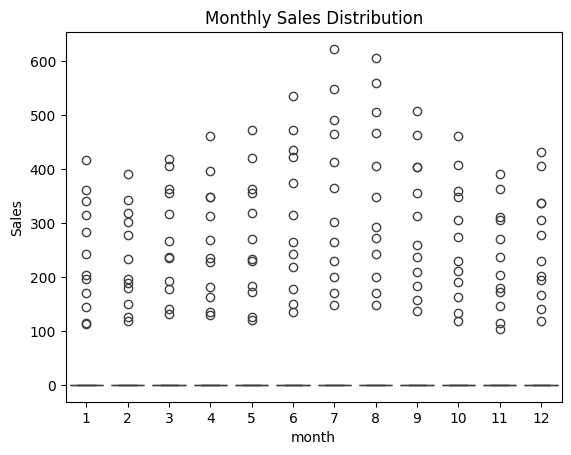

In [6]:
daily_sales['month'] = daily_sales['Date'].dt.month
sns.boxplot(x='month', y='Sales', data=daily_sales)
plt.title("Monthly Sales Distribution")
plt.show()


In [7]:
daily_sales['day'] = daily_sales['Date'].dt.day
daily_sales['month'] = daily_sales['Date'].dt.month
daily_sales['year'] = daily_sales['Date'].dt.year
daily_sales['dayofweek'] = daily_sales['Date'].dt.dayofweek

# Lag feature
daily_sales['lag_1'] = daily_sales['Sales'].shift(1)
daily_sales['lag_7'] = daily_sales['Sales'].shift(7)

daily_sales = daily_sales.dropna()


In [8]:
train = daily_sales[daily_sales['Date'] < '1960-01-01']
test = daily_sales[daily_sales['Date'] >= '1960-01-01']

X_train = train.drop(['Date','Sales'], axis=1)
y_train = train['Sales']

X_test = test.drop(['Date','Sales'], axis=1)
y_test = test['Sales']

In [9]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)


In [10]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE: 1.8560863095238094
RMSE: 11.169555384397315
MAPE: 10.43911897414287


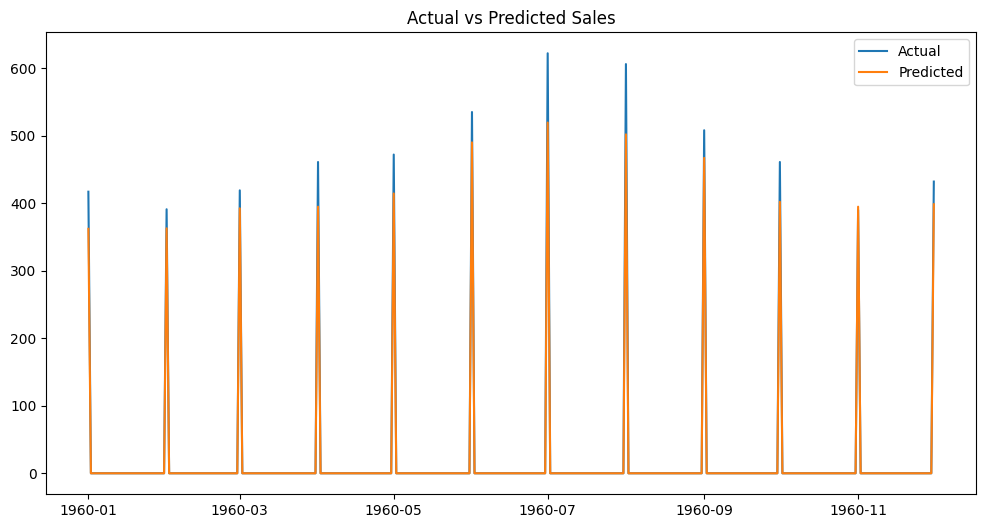

In [11]:
plt.figure(figsize=(12,6))
plt.plot(test['Date'], y_test, label='Actual')
plt.plot(test['Date'], predictions, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()


In [12]:
future_dates = pd.date_range(start=daily_sales['Date'].max(), periods=30)

future_df = pd.DataFrame({'Date': future_dates})
future_df['day'] = future_df['Date'].dt.day
future_df['month'] = future_df['Date'].dt.month
future_df['year'] = future_df['Date'].dt.year
future_df['dayofweek'] = future_df['Date'].dt.dayofweek

# Use last known lag values
future_df['lag_1'] = daily_sales['Sales'].iloc[-1]
future_df['lag_7'] = daily_sales['Sales'].iloc[-7]

# Reorder columns to match X_train
future_predictions = model.predict(future_df[X_train.columns])
future_df['Forecasted_Sales'] = future_predictions

future_df.head()

,Date,day,month,year,dayofweek,lag_1,lag_7,Forecasted_Sales
0,1960-12-01,1,12,1960,3,432,0,398.38
1,1960-12-02,2,12,1960,4,432,0,0.00
2,1960-12-03,3,12,1960,5,432,0,0.00
3,1960-12-04,4,12,1960,6,432,0,0.00
4,1960-12-05,5,12,1960,0,432,0,0.00


In [13]:
future_df['Forecasted_Sales'].sum()


np.float64(398.38)

In [14]:
daily_sales.to_csv('processed_sales.csv', index=False)
future_df.to_csv('forecast_output.csv', index=False)


In [15]:
from google.colab import files
files.download('processed_sales.csv')
files.download('forecast_output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>